# 04 — Evaluation and Error Analysis

## Metrics
All metrics are reported in **basis points** on the held-out test set
(last 20% of bars — never touched during training or validation).

| Metric | Description |
|--------|-------------|
| MAE    | Mean absolute error — primary metric, directly interpretable |
| RMSE   | Root mean squared error — emphasises large errors |
| MedAE  | Median absolute error — robust to outliers |

## Baselines
1. **Mean predictor** — always predicts training-set mean slippage
2. **Linear (Ridge)** — same features, linear model
3. **Heuristic** — β × order_size_fraction × vol_rolling, β calibrated on val

## Error analysis segments
Order size (Q1–Q4) · Volatility (Q1–Q4) · Time of day (open/mid/close) · Buy vs sell · Volume regime

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt

from slippage.features import FEATURE_NAMES_TRAINING
from slippage.pipeline import build_full_dataset
from slippage.models import SlippageMLP
from slippage.training import predict
from slippage.models import MeanPredictor, LinearBaseline, HeuristicBaseline
from slippage.evaluation import global_metrics, segment_breakdown, evaluate_all
from slippage.paths import RESULTS_DIR
from slippage.viz import (
    plot_pred_vs_actual,
    plot_error_by_segment,
    plot_feature_importance,
    FIGURES_DIR,
)

In [2]:
# Rebuild data and split via the shared pipeline. split.test_df is
# guaranteed to align row-by-row with split.y_test / X_test.
data, proxy_all, split = build_full_dataset()
n_tr, n_v, n_te = len(split.X_train), len(split.X_val), len(split.X_test)
print(f'Train: {n_tr:,}  Val: {n_v:,}  Test: {n_te:,}')

test_df = split.test_df  # no more iloc tricks

[data] SPY: 3425 bars (2024-06-05 → 2026-05-22)
[data] QQQ: 3407 bars (2024-06-05 → 2026-05-22)
[data] IWM: 3427 bars (2024-06-05 → 2026-05-22)
[data] AAPL: 3419 bars (2024-06-05 → 2026-05-22)
[data] MSFT: 3419 bars (2024-06-05 → 2026-05-22)
[data] GOOGL: 3424 bars (2024-06-05 → 2026-05-22)
[data] JPM: 3427 bars (2024-06-05 → 2026-05-22)
[data] GS: 3427 bars (2024-06-05 → 2026-05-22)
[data] XOM: 3426 bars (2024-06-05 → 2026-05-22)
[data] SLB: 3427 bars (2024-06-05 → 2026-05-22)
[data] PRCT: 3427 bars (2024-06-05 → 2026-05-22)


Train: 97,331  Val: 22,461  Test: 29,948


In [3]:
# Load trained model
checkpoint = torch.load(RESULTS_DIR / 'model_checkpoint.pt', weights_only=True)
model = SlippageMLP(n_features=checkpoint['n_features'])
model.load_state_dict(checkpoint['state_dict'])
y_pred_mlp = predict(model, split.X_test)
y_test = split.y_test

In [4]:
# Fit baselines
mean_pred = MeanPredictor().fit(split.X_train, split.y_train)
linear_pred = LinearBaseline().fit(split.X_train, split.y_train)
heuristic = HeuristicBaseline(FEATURE_NAMES_TRAINING)
heuristic.fit(split.X_val, split.y_val, split.scaler.mean_, split.scaler.scale_)

y_pred_mean = mean_pred.predict(split.X_test)
y_pred_linear = linear_pred.predict(split.X_test)
y_pred_heuristic = heuristic.predict(split.X_test, split.scaler.mean_, split.scaler.scale_)

In [5]:
# Full evaluation: saves metrics.json (global + segment_breakdown + per_ticker) and prints summary
results = evaluate_all(
    split,
    model_predict_fn=lambda X: predict(model, X),
    baselines={
        'linear':    lambda X: linear_pred.predict(X),
        'heuristic': lambda X: heuristic.predict(X, split.scaler.mean_, split.scaler.scale_),
        'mean':      lambda X: mean_pred.predict(X),
    },
)
print(f'Full metrics (incl. segment_breakdown + per_ticker) saved to {RESULTS_DIR}/metrics.json\n')

# Filter to top-level model-metric entries only — skip the nested per_ticker / segment_breakdown
# entries that would otherwise explode into ticker-name columns.
metrics_df = pd.DataFrame({
    k: {kk: vv for kk, vv in v.items() if kk != 'segment_breakdown'}
    for k, v in results.items()
    if isinstance(v, dict) and 'mae_bps' in v
}).T
print('=== Global Metrics (test set, bps) ===')
print(metrics_df.round(3).to_string())

Full metrics (incl. segment_breakdown + per_ticker) saved to /Users/francesconatale/Documents/projects/slippage-predictor/results/metrics.json

=== Global Metrics (test set, bps) ===
           mae_bps  rmse_bps  med_ae_bps
mlp         31.999    44.847      24.506
linear       7.992    14.803       5.377
heuristic   12.121    21.148       7.297
mean        17.723    31.637      12.733


In [6]:
# Per-ticker MAE breakdown — sorted by MLP MAE ascending
per_ticker = results.get('per_ticker', {})
if per_ticker:
    pt_df = pd.DataFrame(per_ticker).T
    pt_df = pt_df.sort_values('mlp_mae_bps')[
        ['n_samples', 'mlp_mae_bps', 'heuristic_mae_bps',
         'mlp_rmse_bps', 'heuristic_rmse_bps']
    ]
    print('=== Per-ticker MAE (sorted by MLP MAE) ===')
    print(pt_df.round(3).to_string())

=== Per-ticker MAE (sorted by MLP MAE) ===
       n_samples  mlp_mae_bps  heuristic_mae_bps  mlp_rmse_bps  heuristic_rmse_bps
SPY       2732.0       14.571              5.711        17.647               8.443
QQQ       2680.0       19.434              7.421        22.592              10.539
IWM       2732.0       23.154              8.822        27.752              12.988
AAPL      2710.0       25.583              9.768        30.559              14.070
JPM       2736.0       27.196             10.290        31.851              14.526
GOOGL     2720.0       30.220             11.343        35.834              16.454
XOM       2732.0       30.440             11.278        36.706              16.638
MSFT      2706.0       32.050             12.292        42.545              20.399
GS        2732.0       36.552             13.777        42.936              19.738
SLB       2733.0       38.243             14.464        46.862              21.380
PRCT      2735.0       74.203             28

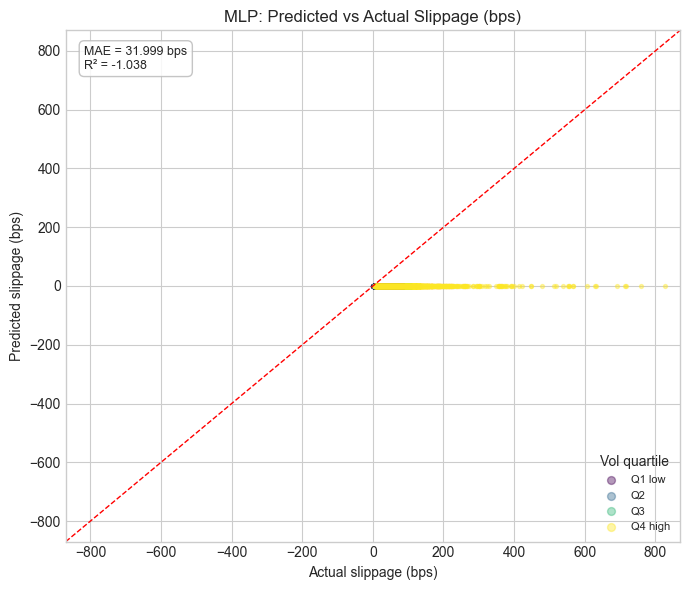

In [7]:
# Predicted vs actual — coloured by vol regime
vol_q = pd.qcut(test_df['vol_rolling'], q=4, labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])
fig = plot_pred_vs_actual(
    y_test, y_pred_mlp,
    regime=vol_q.values,
    regime_label='Vol quartile',
    title='MLP: Predicted vs Actual Slippage (bps)',
    save_as='pred_vs_actual.png',
)
plt.show()

      segment         bucket  n_samples   mae_bps  rmse_bps  med_ae_bps
size_quartile       Q1_small       7487 16.693937 22.666162   12.779797
size_quartile             Q2       7487 28.980265 37.843524   23.044478
size_quartile             Q3       7487 37.114087 48.995528   29.352502
size_quartile       Q4_large       7487 45.206774 60.814589   35.643835
 vol_quartile     Q1_low_vol       7490 14.801625 16.936639   13.471570
 vol_quartile             Q2       7487 22.681719 25.370393   21.115491
 vol_quartile             Q3       7484 30.966720 34.505616   29.040101
 vol_quartile    Q4_high_vol       7487 59.551477 76.968053   49.754583
  time_of_day           open       4268 38.860619 56.099685   29.725521
  time_of_day            mid      21376 30.116492 41.757707   23.082987
  time_of_day          close       4304 34.542702 47.046324   26.824972
         side            buy      14973 32.013322 44.290046   24.567314
         side           sell      14975 31.984212 45.396220   24

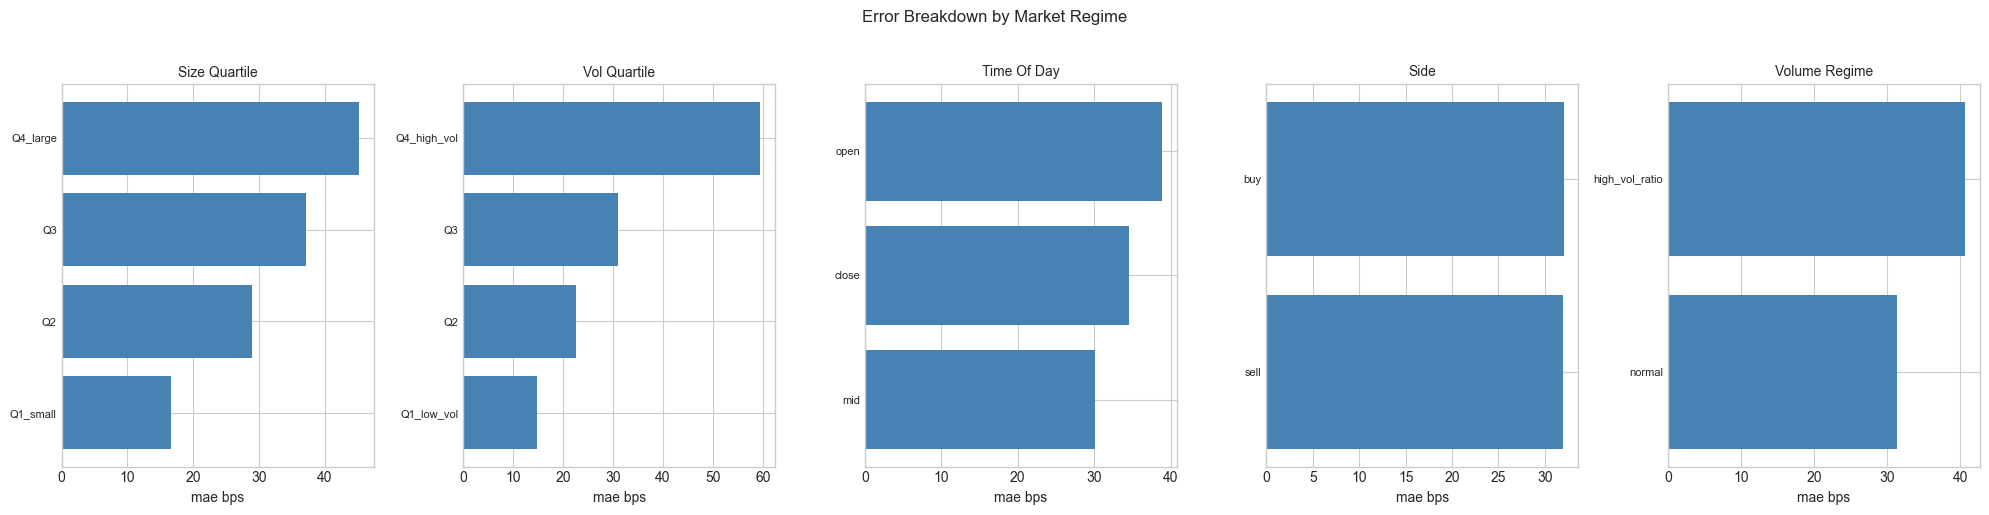

In [8]:
# Error breakdown by segment
breakdown = segment_breakdown(y_test, y_pred_mlp, test_df)
print(breakdown.to_string(index=False))
fig = plot_error_by_segment(breakdown, metric='mae_bps', save_as='error_by_segment.png')
plt.show()

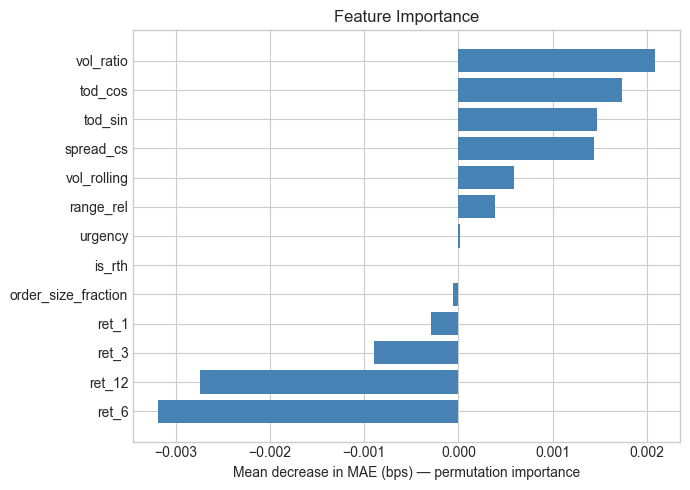

All figures saved to results/figures/


In [9]:
# Feature importance (permutation, on val set)
fig = plot_feature_importance(
    model, split.X_val, split.y_val, FEATURE_NAMES_TRAINING,
    n_repeats=5, seed=42, save_as='feature_importance.png',
)
plt.show()
print('All figures saved to results/figures/')